In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


print("Loading data...")
df = pd.read_csv('data/DataCoSupplyChainDataset.csv', encoding='latin1')

pd.set_option('display.max_columns', None)

print(f"Dataset Shape: {df.shape}")
display(df.head(3))

Loading data...
Dataset Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


--- Missing Values ---
Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64

New Shape after dropping useless columns: (180519, 46)


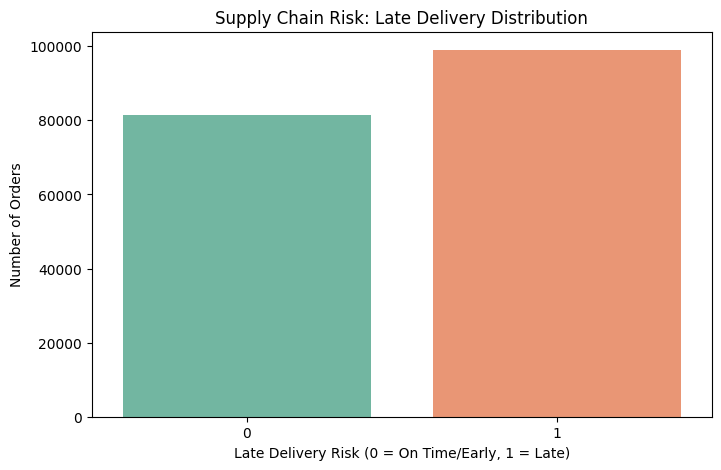


Exact Breakdown:
Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


In [3]:
# 1. Let's find out which columns have missing data (NaN/Nulls)
print("--- Missing Values ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# 2. Drop columns that are useless for predicting supply chain delays (Personal Info, URLs, etc.)
columns_to_drop = [
    'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname',
    'Product Image', 'Product Description', 'Order Zipcode' 
]

# Create a clean version of the dataframe
df_clean = df.drop(columns=columns_to_drop)
print(f"\nNew Shape after dropping useless columns: {df_clean.shape}")

# 3. Visualize our Target Variable (What we want the AI to predict)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Late_delivery_risk', palette='Set2')
plt.title('Supply Chain Risk: Late Delivery Distribution')
plt.xlabel('Late Delivery Risk (0 = On Time/Early, 1 = Late)')
plt.ylabel('Number of Orders')
plt.show()

# Print the exact numbers
print("\nExact Breakdown:")
print(df_clean['Late_delivery_risk'].value_counts(normalize=True) * 100)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("Selecting features and encoding data...")

# 1. Select the features that actually impact delivery times
features = [
    'Type', 'Shipping Mode', 'Category Name', 'Order Region', 
    'Order Country', 'Order Item Quantity', 'Product Price'
]
X = df_clean[features].copy()
y = df_clean['Late_delivery_risk'].copy()

# 2. Convert text columns to numbers using LabelEncoder
encoder_dict = {} # We save the encoders in case we need to decode later
categorical_cols = ['Type', 'Shipping Mode', 'Category Name', 'Order Region', 'Order Country']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoder_dict[col] = le

print("\nData after converting text to numbers (First 3 rows):")
display(X.head(3))

# 3. Split the data: 80% for Training the AI, 20% for Testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Selecting features and encoding data...

Data after converting text to numbers (First 3 rows):


,Type,Shipping Mode,Category Name,Order Region,Order Country,Order Item Quantity,Product Price
0,1,3,40,15,70,1,327.75
1,3,3,40,13,69,1,327.75
2,0,3,40,13,69,1,327.75



Training Data Shape: (144415, 7)
Testing Data Shape: (36104, 7)


In [5]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import pickle

print("Training the XGBoost AI Model. This might take 10-30 seconds...")

# 1. Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Train the model on the 80% Training Data
xgb_model.fit(X_train, y_train)

# 3. Make predictions on the 20% Testing Data we hid from the model
y_pred = xgb_model.predict(X_test)

# 4. Grade the AI's test
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Training Complete!")
print(f"✅ AI Accuracy Score: {accuracy * 100:.2f}%\n")

print("Detailed Performance Report:")
print(classification_report(y_test, y_pred))

# 5. VERY IMPORTANT: Save the trained model to a file
# We will load this exact file into our Real-Time Kafka Pipeline later!
with open('supply_chain_risk_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)
    
print("\n💾 Model successfully saved as 'supply_chain_risk_model.pkl' in your data-pipeline folder!")

Training the XGBoost AI Model. This might take 10-30 seconds...

✅ Model Training Complete!
✅ AI Accuracy Score: 69.32%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.61      0.87      0.72     16307
           1       0.83      0.55      0.66     19797

    accuracy                           0.69     36104
   macro avg       0.72      0.71      0.69     36104
weighted avg       0.73      0.69      0.69     36104


💾 Model successfully saved as 'supply_chain_risk_model.pkl' in your data-pipeline folder!
